# COGS 138 Final Project: Alzheimer Disease Transcriptomics

**Research question:** Can single-nucleus RNA-seq expression profiles distinguish Alzheimer disease (AD)
donors from healthy controls, and which biological signals support that separation?

Hypothesis: Donor level pseudobulk transcriptomic profiles taken from sn-RNA seq data will significantly distinguish Alzhiemers disease donors from healthy controls. The AD donors exhibit dysregulation in genes associated with neuroinflammation, synpatic dysfunction and amyliod processing; these expression differences will be sufficient for above-chance classification using classical machine learning methods despite small sample sizes.

The original project proposal aimed to compare transformer-based gene-expression embeddings against
classical machine-learning baselines across AD and Parkinson disease. The Parkinson dataset was too large
to load reliably in the available environment, so this final notebook focuses on a complete, reproducible
AD-versus-control analysis using the Alzheimer disease dataset from GEO accession **GSE174367**.

The final workflow uses donor-level pseudobulk profiles rather than treating each nucleus as an independent
sample. This avoids data leakage from training and testing on cells from the same person.

## Background and Motivation

Alzheimer disease is a neurodegenerative disorder involving changes in neuronal and glial biology.
Single-nucleus RNA sequencing is useful for this question because it measures gene expression in individual
brain-cell nuclei, allowing us to ask whether disease state is reflected in transcriptomic structure.

Recent foundation-model papers such as scGPT, Geneformer, and scBERT motivate the broader idea that learned
gene-expression representations may capture biological state. This notebook does not claim to complete that
full foundation-model comparison. Instead, it builds the necessary classical baseline: a transparent,
reproducible AD-versus-control analysis that can later be compared against scGPT or Geneformer embeddings.

References from the proposal: Cui et al. 2024, *Nature Methods*; Theodoris et al. 2023, *Nature*; Yang et al.
2022, *Nature Machine Intelligence*.

## Computational Workflow

1. Download the GSE174367 single-nucleus RNA-seq metadata and 10x expression matrix.
2. Align cell barcodes between metadata and the expression matrix.
3. Aggregate nuclei into donor-level pseudobulk expression profiles.
4. Normalize expression to log counts per million and select highly variable genes.
5. Visualize donor profiles using PCA and UMAP.
6. Compare AD and control donors using leave-one-donor-out classifiers.
7. Summarize cell-type composition and highly variable genes associated with diagnosis.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib as plt
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from IPython.display import Image, display
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from scripts.final_ad_analysis import run_analysis

processed = Path("data/processed")
required = [
    processed / "ad_sample_metadata.csv",
    processed / "classifier_results.csv",
    processed / "top_hvg_differential_expression.csv",
    processed / "cell_type_composition_tests.csv",
]

if not all(path.exists() for path in required):
    run_analysis()

sample_meta = pd.read_csv(processed / "ad_sample_metadata.csv", index_col=0)
classifier_results = pd.read_csv(processed / "classifier_results.csv")
de = pd.read_csv(processed / "top_hvg_differential_expression.csv")
composition = pd.read_csv(processed / "cell_type_composition_tests.csv")
pca_variance = pd.read_csv(processed / "pca_variance.csv")

## Dataset

The analysis uses GSE174367, a single-nucleus transcriptomic dataset with AD and control nuclei.
The raw cell-level matrix contains tens of thousands of nuclei, but model evaluation is done at the
donor level because diagnosis is a donor-level label.

In [2]:
print(f"Number of donors: {sample_meta.shape[0]}")
print(f"Total matched nuclei: {sample_meta['n_cells'].sum():,}")
display(sample_meta)
display(sample_meta['Diagnosis'].value_counts().rename_axis('Diagnosis').to_frame('n_donors'))

Number of donors: 18
Total matched nuclei: 61,472


,Diagnosis,Age,Sex,Batch,n_cells
SampleID,,,,,
Sample-100,Control,79,M,1,4575
Sample-17,AD,90,F,3,3797
Sample-19,AD,90,F,3,3049
Sample-22,AD,86,M,2,2863
Sample-27,AD,81,M,2,3737
Sample-33,AD,80,M,3,2674
Sample-37,AD,87,F,3,3874
Sample-43,AD,90,F,1,4835
Sample-45,AD,89,F,1,4717


,n_donors
Diagnosis,
AD,11
Control,7


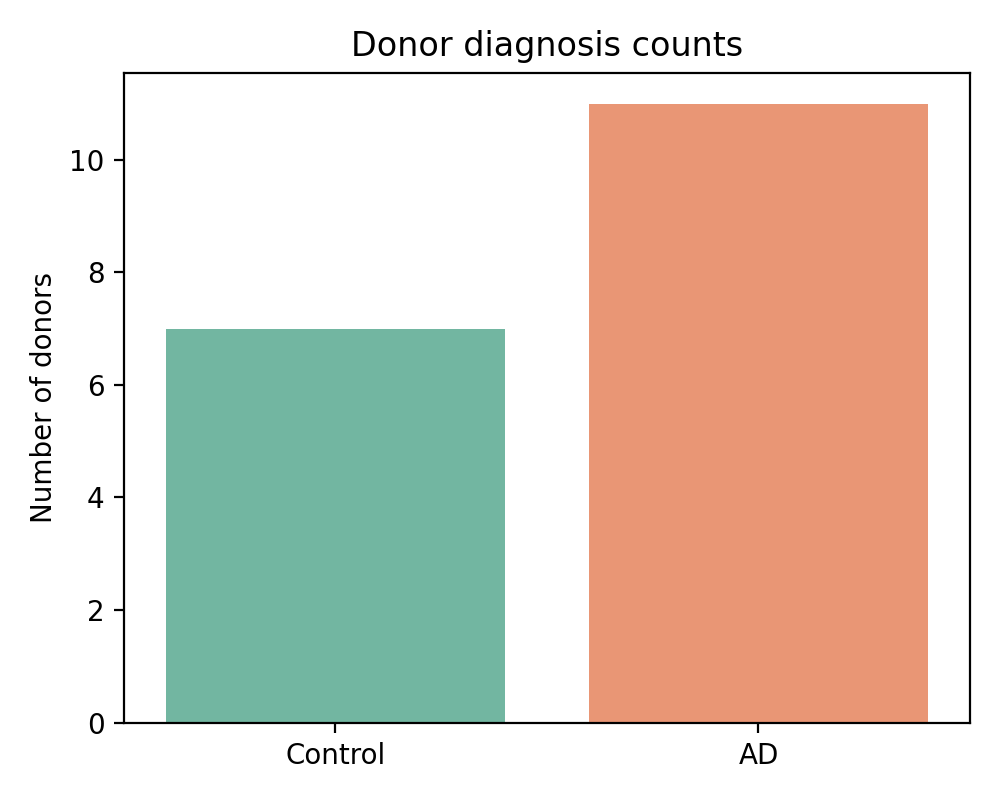

In [3]:
display(Image(filename="figures/diagnosis_counts.png"))

## Cell-Type Composition

Before looking at expression, we checked whether AD and control samples differ in broad cell-type
composition. This is useful because disease-related expression differences can be confounded by different
proportions of neurons, glia, and vascular cells.

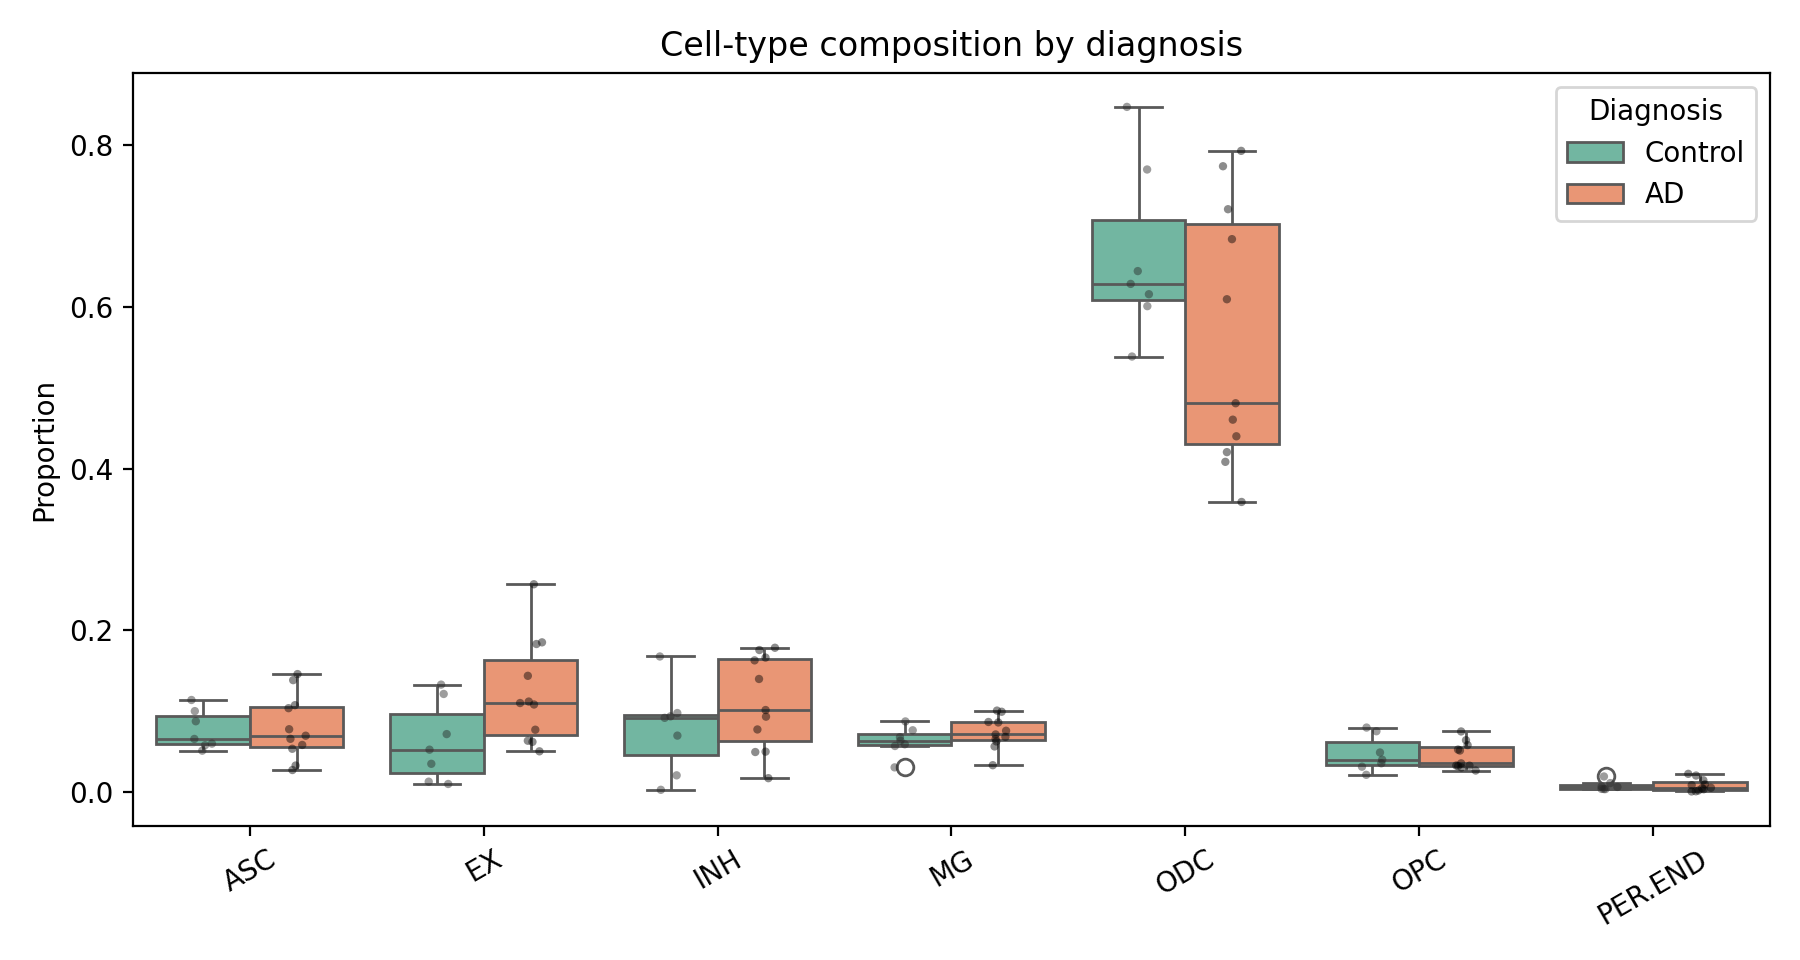

,Cell.Type,AD_mean,Control_mean,Difference_AD_minus_Control,Welch_t,p_value
0,EX,0.123146,0.062557,0.060589,2.260030,0.038860
1,ODC,0.558962,0.663400,-0.104438,-1.658895,0.116715
2,INH,0.110395,0.077973,0.032422,1.203457,0.249543
3,MG,0.073516,0.063360,0.010155,1.132727,0.276471
4,OPC,0.044929,0.047720,-0.002791,-0.287556,0.779514
5,ASC,0.080298,0.076853,0.003445,0.230467,0.820650
6,PER.END,0.008754,0.008137,0.000618,0.196021,0.847147


In [4]:
display(Image(filename="figures/cell_type_composition.png"))
display(composition)

## Expression-Space Structure

PCA and UMAP were run on donor pseudobulk log-CPM expression for the top highly variable genes.
PCA is the main baseline representation because it is transparent and appropriate for a small number of
donor-level observations.

,component,explained_variance_ratio
0,1,0.564525
1,2,0.118218
2,3,0.056565
3,4,0.045732
4,5,0.031675
5,6,0.026768
6,7,0.023956
7,8,0.021157
8,9,0.019273
9,10,0.017497


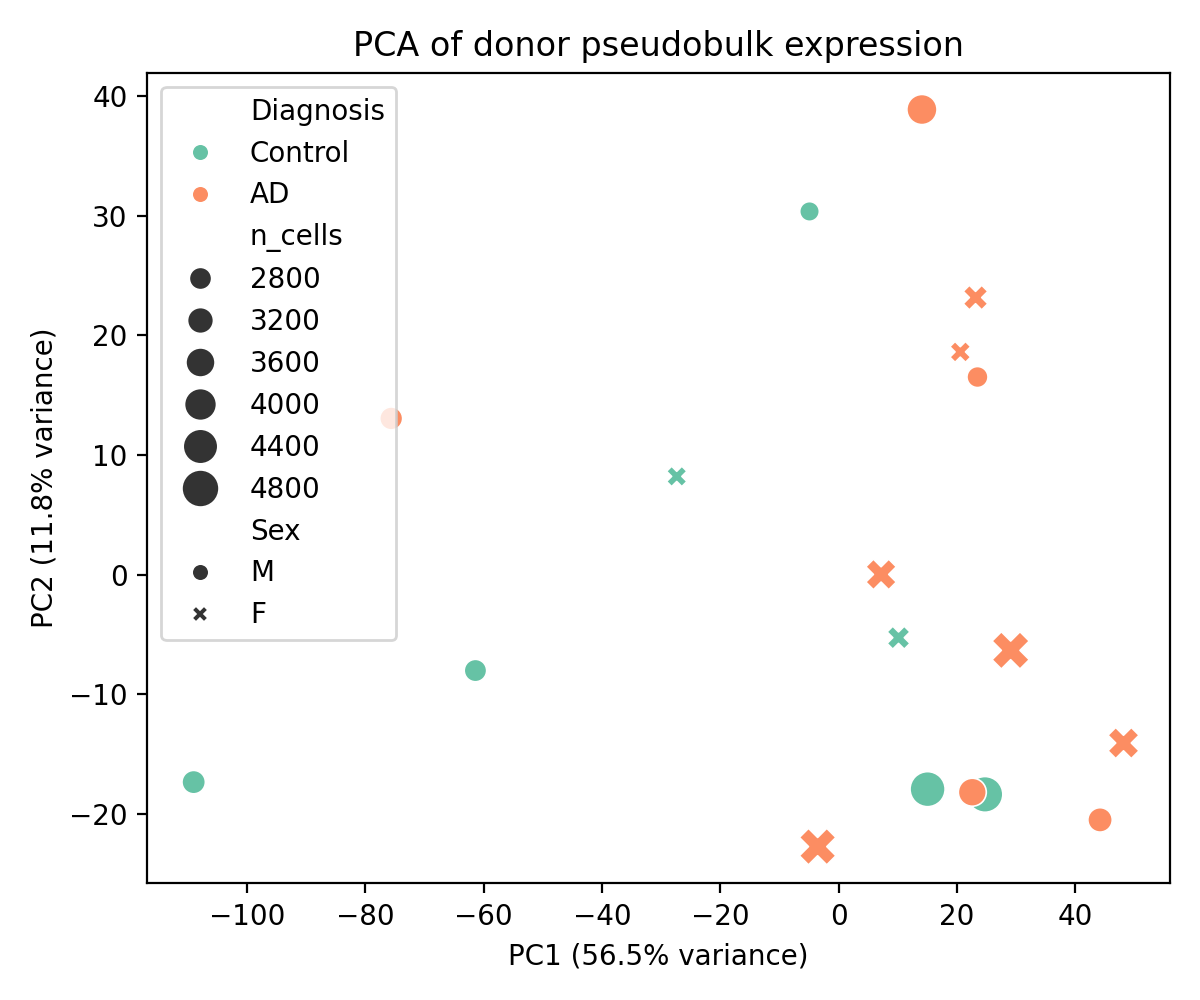

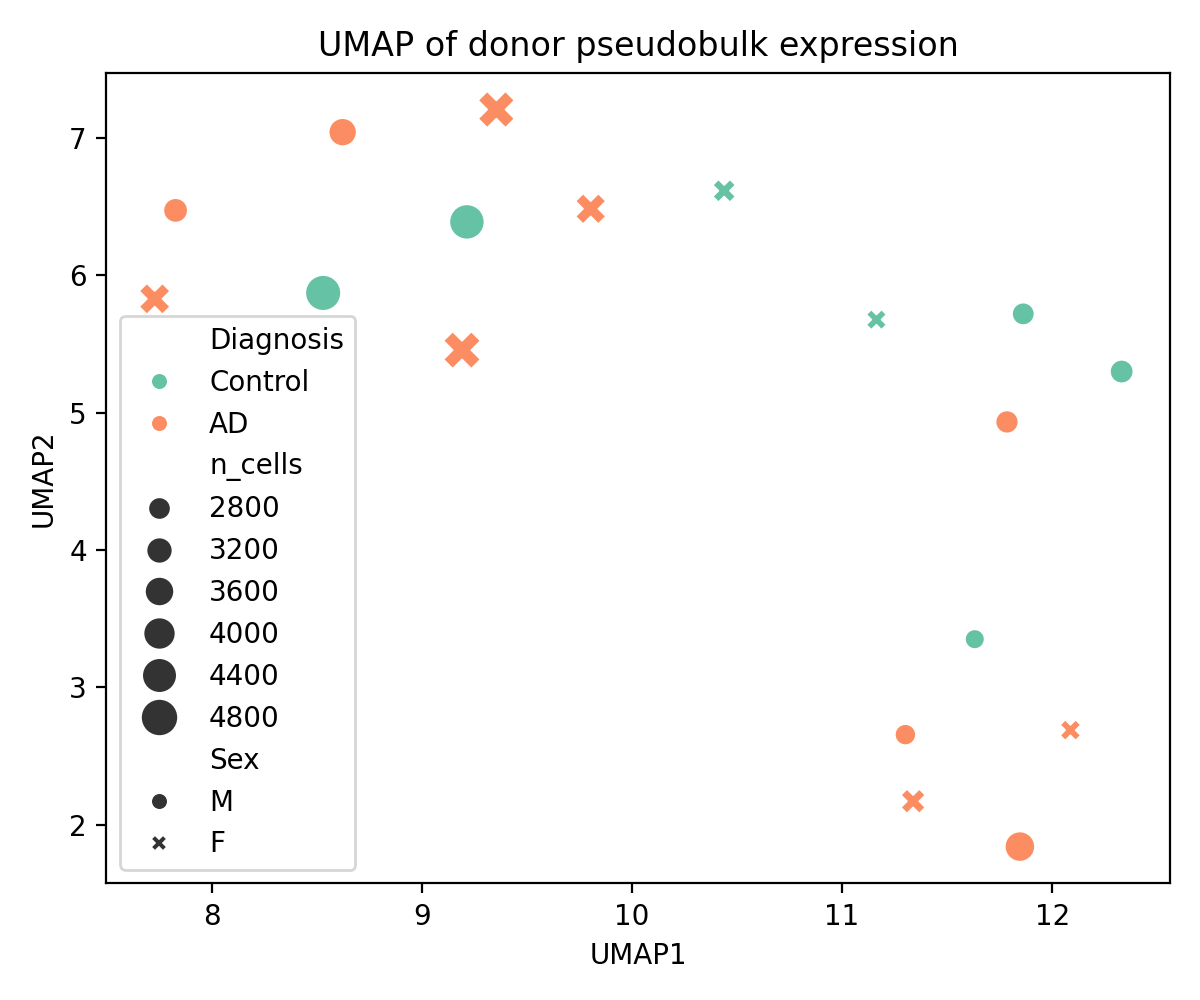

In [5]:
display(pca_variance.head(10))
display(Image(filename="figures/pca_pseudobulk.png"))
display(Image(filename="figures/umap_pseudobulk.png"))

## Classification Baselines

Two classical baselines were evaluated with leave-one-donor-out cross-validation:

- Logistic regression trained on PCA features.
- Random forest trained on the selected highly variable genes.

Leave-one-donor-out cross-validation is strict for this dataset because the model must predict a donor
it did not see during training.

,model,accuracy,balanced_accuracy,confusion_matrix
0,Logistic regression on PCA features,0.666667,0.649351,"[[8, 3], [3, 4]]"
1,Random forest on HVGs,0.611111,0.577922,"[[8, 3], [4, 3]]"


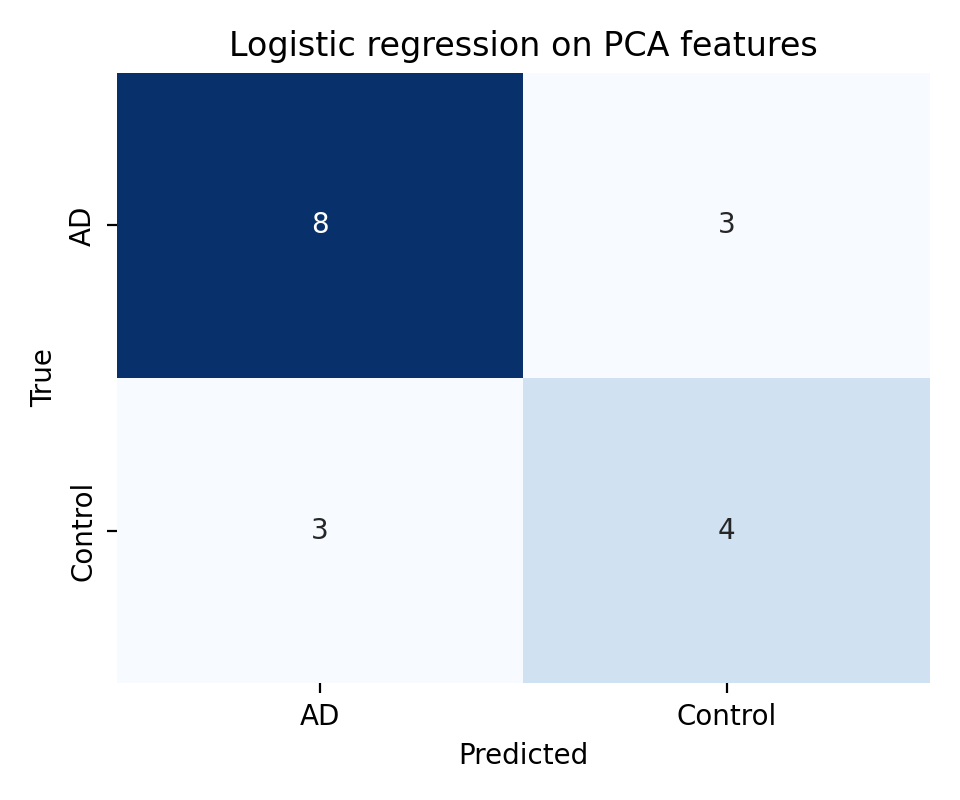

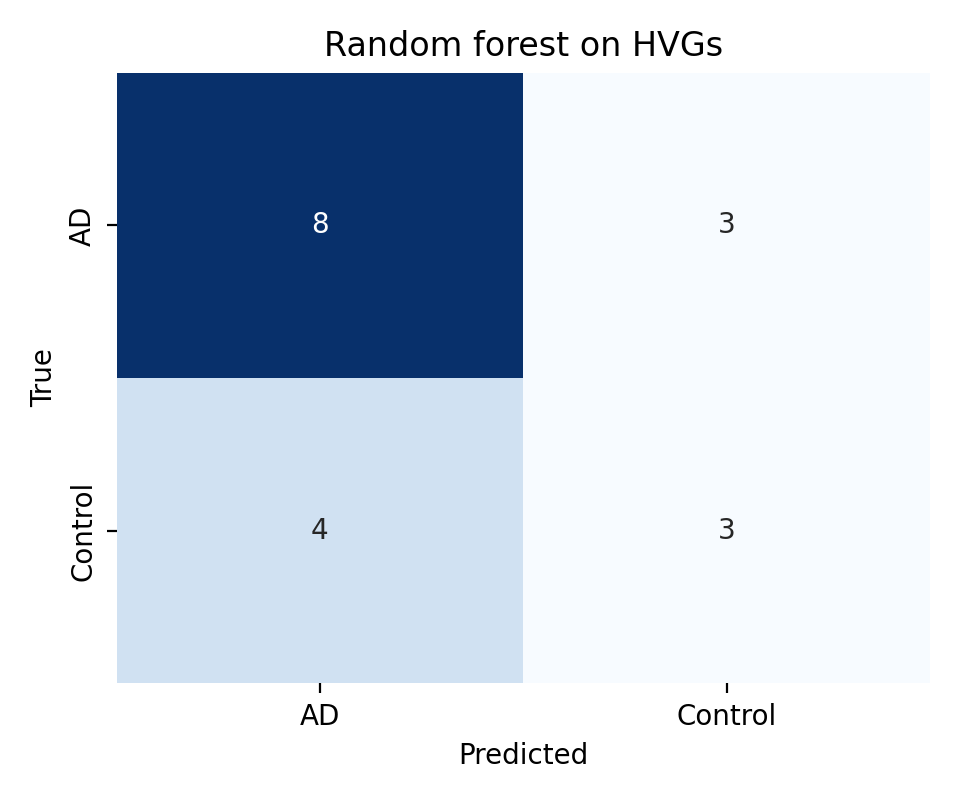

In [ ]:
display(classifier_results)
display(Image(filename="figures/confusion_logistic_regression_on_pca_features.png"))
display(Image(filename="figures/confusion_random_forest_on_hvgs.png"))



## Differential Expression Screen

The table below is an exploratory Welch t-test screen across the selected highly variable genes.
Because there are only 18 donors, these genes should be interpreted as candidates that help describe the
dataset, not as validated biomarkers.

In [7]:
display(de.head(20))

,gene,AD_mean,Control_mean,logCPM_difference_AD_minus_Control,Welch_t,p_value
0,ADCY10,2.556186,1.858094,0.698093,4.071826,0.000915
1,AC018742.1,1.990350,1.169609,0.820741,4.034152,0.001085
2,CNP,4.932846,5.622588,-0.689742,-3.860223,0.001500
3,EGF,2.147614,1.425626,0.721988,3.795809,0.001587
4,C5orf64,4.286125,4.936649,-0.650525,-3.869376,0.001676
5,LINC01608,5.529545,6.212311,-0.682766,-3.898846,0.001724
6,HSPH1,4.473908,3.653879,0.820029,3.808584,0.001855
7,RHOG,2.432930,3.192781,-0.759851,-3.842079,0.001883
8,GREB1L,4.604208,5.232930,-0.628722,-3.701933,0.001945
9,OPALIN,4.104592,4.970601,-0.866008,-3.656509,0.002266


## Interpretation

The donor-level expression profiles contain AD-related signal, but the separation is not perfect.
Logistic regression on PCA features achieved approximately 0.67 accuracy and 0.65 balanced accuracy under
leave-one-donor-out validation, while the random forest baseline performed slightly worse. This suggests
that a low-dimensional expression representation captures some disease structure, but the small number of
donors limits classification performance.

The cell-type analysis showed a higher mean excitatory-neuron proportion in AD donors in this dataset,
while most other broad cell types were not clearly different. This matters because disease status may be
reflected both in gene-expression changes within cell types and in shifts in cell-type composition.

Overall, the completed analysis supports a cautious conclusion: AD and control samples are partially
separable from single-nucleus expression data using transparent classical methods, but stronger claims
would require more donors, better covariate control, and ideally a transformer embedding comparison such
as scGPT or Geneformer.

## Limitations and Future Work

- The donor sample size is small: 11 AD donors and 7 controls.
- Age, sex, batch, and cell-type composition may confound some disease signal.
- This notebook uses pseudobulk profiles, which are statistically safer for donor-level prediction but
  lose some cell-state resolution.
- The proposed scGPT comparison was not completed here because installing and running the model is a larger
  engineering task than the available project time allowed.
- A stronger extension would run cell-type-specific pseudobulk models and compare PCA features directly
  against pretrained scGPT or Geneformer embeddings.